<a href="https://colab.research.google.com/github/balkiss06/Movie_recommendation/blob/main/movie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MOVIE RECOMMENDATION**


---



---



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ***EDA***
---




In [2]:
d=pd.read_csv("/content/drive/MyDrive/formation/netflix_data.csv")
print(d)

     show_id     type                  title         director  \
0         s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1         s2  TV Show          Blood & Water              NaN   
2         s3  TV Show              Ganglands  Julien Leclercq   
3         s4  TV Show  Jailbirds New Orleans              NaN   
4         s5  TV Show           Kota Factory              NaN   
...      ...      ...                    ...              ...   
8802   s8803    Movie                 Zodiac    David Fincher   
8803   s8804  TV Show            Zombie Dumb              NaN   
8804   s8805    Movie             Zombieland  Ruben Fleischer   
8805   s8806    Movie                   Zoom     Peter Hewitt   
8806   s8807    Movie                 Zubaan      Mozez Singh   

                                                   cast        country  \
0                                                   NaN  United States   
1     Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa 

In [3]:
d.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [4]:
print(d.columns)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')


In [5]:
print(d["show_id"].value_counts())

show_id
s8807    1
s1       1
s2       1
s3       1
s4       1
        ..
s12      1
s11      1
s10      1
s9       1
s8       1
Name: count, Length: 8807, dtype: int64


type
Movie      6131
TV Show    2676
Name: count, dtype: int64


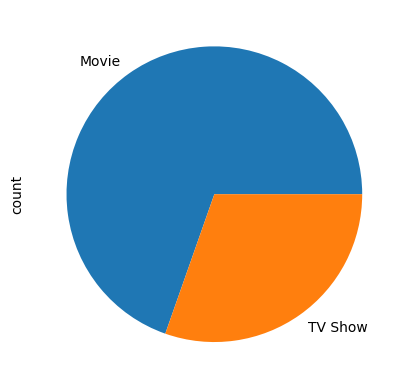

In [6]:
print(d["type"].value_counts())
d["type"].value_counts().plot(kind="pie")
plt.show()

country
United States                                                      2818
India                                                               972
United Kingdom                                                      419
Japan                                                               245
South Korea                                                         199
                                                                   ... 
Mexico, United States, Spain, Colombia                                1
Canada, Norway                                                        1
Finland, Germany, Belgium                                             1
Argentina, United States, Mexico                                      1
United Kingdom, United States, Germany, Denmark, Belgium, Japan       1
Name: count, Length: 748, dtype: int64


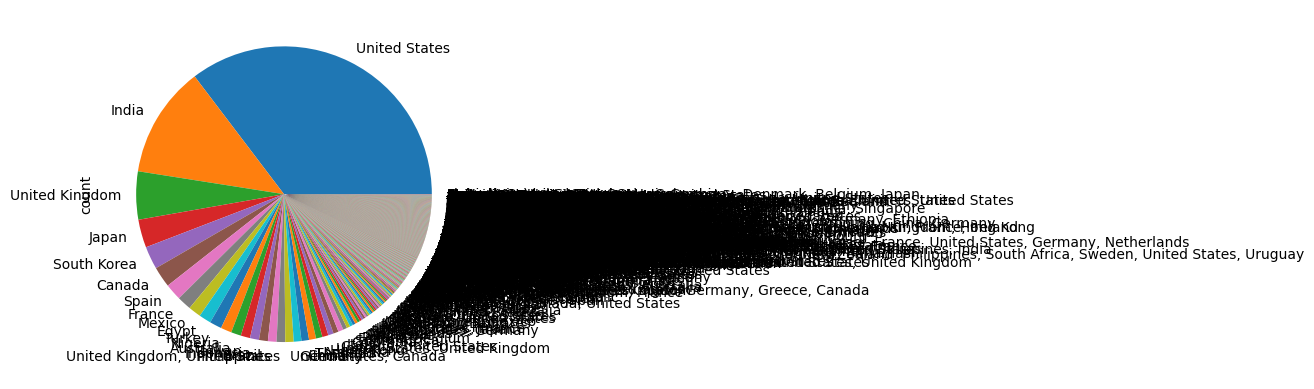

In [7]:
print(d["country"].value_counts())
d["country"].value_counts().plot(kind="pie")
plt.show()

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
        ... 
1961       1
1925       1
1959       1
1966       1
1947       1
Name: count, Length: 74, dtype: int64
2018


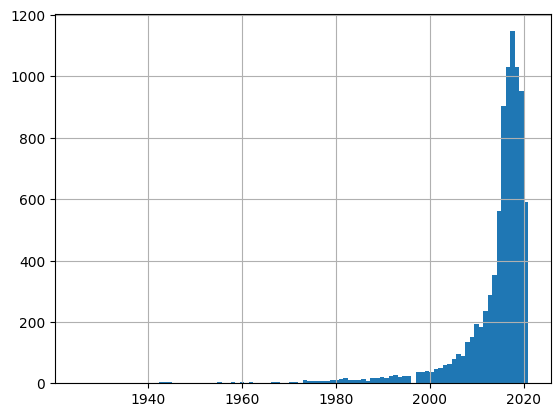

In [8]:
print(d["release_year"].value_counts())
print(d["release_year"].value_counts().idxmax())
d["release_year"].hist(bins=100)
plt.show()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


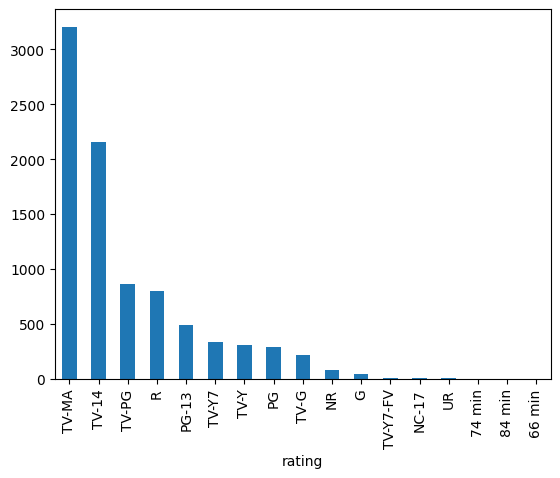

In [9]:
print(d["rating"].value_counts())
d["rating"].value_counts().plot(kind="bar")
plt.show()

In [10]:
print(d.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [11]:
print(d.duplicated().sum())

0


# ***PRETRAITEMENT***


---



In [12]:
d.loc[d["rating"] == "74 min", "rating"] = "UR"
d.loc[d["rating"] == "84 min", "rating"] = "UR"
d.loc[d["rating"] == "66 min", "rating"] = "UR"
print(d["rating"].value_counts())


rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
UR             6
TV-Y7-FV       6
NC-17          3
Name: count, dtype: int64


In [13]:
d.fillna("", inplace=True)

In [14]:
d["movies"] = (d["show_id"]+" "+d["type"]+" "+d['title']+" "+d["director"]+ " "+
    d["cast"]+" "+d["country"]+" "+d["date_added"]+" "+d["release_year"].astype(str)+" "+
    d["rating"]+" "+d["duration"]+" "+d["listed_in"]+" "+d["description"])

In [15]:
print(d["movies"])

0       s1 Movie Dick Johnson Is Dead Kirsten Johnson ...
1       s2 TV Show Blood & Water  Ama Qamata, Khosi Ng...
2       s3 TV Show Ganglands Julien Leclercq Sami Boua...
3       s4 TV Show Jailbirds New Orleans    September ...
4       s5 TV Show Kota Factory  Mayur More, Jitendra ...
                              ...                        
8802    s8803 Movie Zodiac David Fincher Mark Ruffalo,...
8803    s8804 TV Show Zombie Dumb    July 1, 2019 2018...
8804    s8805 Movie Zombieland Ruben Fleischer Jesse E...
8805    s8806 Movie Zoom Peter Hewitt Tim Allen, Court...
8806    s8807 Movie Zubaan Mozez Singh Vicky Kaushal, ...
Name: movies, Length: 8807, dtype: object


# **MODELE**

---



In [16]:
t = TfidfVectorizer(stop_words="english")
movies_matrix = t.fit_transform(d["movies"])

def recommend(name, n):
    name_vec = t.transform([name])
    similarity = cosine_similarity(name_vec, movies_matrix).flatten()
    indices = similarity.argsort()[-n:][::-1]
    ligne = d.iloc[indices]
    return ligne

recommend("Comedy",10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,movies
2978,s2979,Movie,Kevin Hart: I'm a Grown Little Man,Shannon Hartman,Kevin Hart,United States,"January 30, 2020",2009,TV-MA,62 min,Stand-Up Comedy,Stand-up comedy star Kevin Hart delivers his u...,s2979 Movie Kevin Hart: I'm a Grown Little Man...
7812,s7813,TV Show,Queens of Comedy,,,,"May 1, 2018",2017,TV-MA,1 Season,"International TV Shows, Stand-Up Comedy & Talk...",Eight women perform in front of celebrity judg...,"s7813 TV Show Queens of Comedy May 1, 2018 ..."
4674,s4675,TV Show,The Comedy Lineup,,"Michelle Buteau, Ian Karmel, Taylor Tomlinson,...",United States,"August 31, 2018",2018,TV-MA,2 Seasons,"Stand-Up Comedy & Talk Shows, TV Comedies",A diverse group of up-and-coming comedians per...,s4675 TV Show The Comedy Lineup Michelle Bute...
4128,s4129,Movie,"Ray Romano: Right Here, Around the Corner",Michael Showalter,Ray Romano,United States,"February 5, 2019",2019,TV-MA,59 min,Stand-Up Comedy,Ray Romano cut his stand-up teeth at the Comed...,"s4129 Movie Ray Romano: Right Here, Around the..."
6519,s6520,TV Show,Comedy Bang! Bang!,,"Scott Aukerman, Reggie Watts",United States,"December 28, 2016",2016,TV-14,5 Seasons,"Stand-Up Comedy & Talk Shows, TV Comedies",Scott Aukerman brings his popular podcast Come...,s6520 TV Show Comedy Bang! Bang! Scott Aukerm...
475,s476,Movie,The Stand-Up,Daniel Růžička,"Iva Pazderková, Lukáš Pavlásek, Daniel Čech, P...",,"July 10, 2021",2019,TV-MA,93 min,Stand-Up Comedy,Members of the comedy group Na Stojáka take th...,s476 Movie The Stand-Up Daniel Růžička Iva Paz...
4846,s4847,TV Show,The Break with Michelle Wolf,,,United States,"May 27, 2018",2018,TV-MA,1 Season,"Stand-Up Comedy & Talk Shows, TV Comedies",Nobody's safe as Michelle Wolf unapologeticall...,s4847 TV Show The Break with Michelle Wolf U...
242,s243,TV Show,Comedy Premium League,,,,"August 20, 2021",2021,TV-MA,1 Season,"International TV Shows, TV Comedies","With satirical sketches, cheeky debates and bl...",s243 TV Show Comedy Premium League August 2...
5261,s5262,Movie,Def Comedy Jam 25,Louis J. Horvitz,"Dave Chappelle, Steve Harvey, Cedric the Enter...",United States,"September 26, 2017",2017,TV-MA,82 min,Stand-Up Comedy,"In this special live event, giants of stand-up...",s5262 Movie Def Comedy Jam 25 Louis J. Horvitz...
5078,s5079,Movie,Katt Williams: Great America,,Katt Williams,United States,"January 16, 2018",2018,TV-MA,60 min,Stand-Up Comedy,The King of underground comedy delivers unflin...,s5079 Movie Katt Williams: Great America Katt...


# **EVALUATION**


---






In [17]:
def precision_at_k(m, k):
    results = recommend(m, k)
    relevant = 0

    for index, row in results.iterrows():
        text = row["movies"].lower()
        if m.lower() in text:
            relevant += 1
    return (relevant/k)

precision_at_k("Comedy",10)

1.0

In [18]:
def recall_at_k(m, k):
    total=d["movies"].str.lower().str.contains(m.lower()).sum()
    results = recommend(m, k)
    relevant = 0

    for index, row in results.iterrows():
        text = row["movies"].lower()

        if m.lower() in text:
            relevant += 1

    return (relevant /total)
recall_at_k("Comedy",10)

np.float64(0.019762845849802372)

In [19]:
def f1_score_at_k(m,k):
  total=d["movies"].str.lower().str.contains(m.lower()).sum()
  if total==0:
    return 0
  else:
    precision = precision_at_k(m, k)
    recall = recall_at_k(m,k)

    if precision + recall == 0:
        return 0

    return 2 * (precision * recall) / (precision + recall)

print(f1_score_at_k("Comedy",10))

0.03875968992248062
